In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import sys
sys.path.append("../../src/")

from micromet import simulate_alfalfa_height_multi_field
from micromet import AlfalfaHeightParams


In [46]:

meas_height = [
 ["2/8/2023", 0.1],
 ["4/26/2023", 0.1],
 ["6/5/2023", 2.2],
 ['6/23/2023', 2.2],
 ["6/24/2023", 0.1],
 ["7/18/2023", 2],
 ["7/26/2023", 2.1],
 ["7/27/2023", 0.1],
 ["8/31/2023", 1.75],
 ["9/7/2023", 0.1],
 ["9/19/2023", 0.427],
 ["10/24/2023", 0.722],
 ["11/14/2023", 1.8],
["11/15/2023", 0.1],
 ["5/16/2024", 0.984],
 ["6/6/2024", 1.6],
 ["6/19/2024", 2],
 ["6/23/2024", 2.2],
 ["6/24/2024", 0.1],
 ["7/23/2024", 1.312],
 ["8/9/2024", 2.2],
 ["8/22/2024", 0.3],
 ["9/15/2024", 0.6],
 ["10/8/2024", 1.417],
 ["11/06/2024", 2.0],
 ["11/8/2024", 0.1],
 ["12/11/2024", 0.1],
]

meas_df = pd.DataFrame(meas_height, columns=["date", "value"])
meas_df["date"] = pd.to_datetime(meas_df["date"])

meas_df['height_cm'] = meas_df['value'] * 2.54 * 12  

Index(['ppt (mm)', 'tmean (degrees C)'], dtype='object')

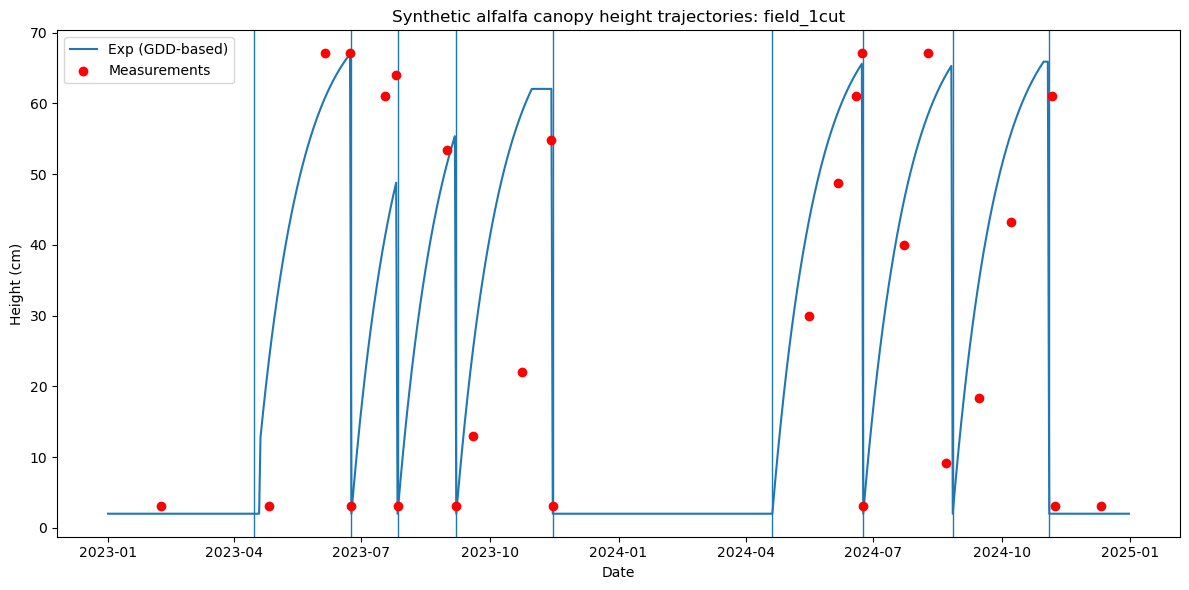

In [70]:

weather = pd.read_csv("PRISM_wellington.csv", parse_dates=["Date"],index_col="Date")
weather = weather.rename(columns={'tmean (degrees C)':'tmean_c'})
#
# # --- Synthetic cut schedules (1–4 cuts) ---
cut_schedules = {
    "field_1cut":  [ "4/15/2023",
        "4/20/2024",
                     "6/24/2023",
                     "7/27/2023",
                     "9/7/2023",
                     "11/15/2023",
                     "6/24/2024",
                     "8/27/2024",
                     "11/4/2024"],
}

# 
#  --- Synthetic modeling period (one year) ---
dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")
doy = dates.dayofyear.to_numpy()

# Same weather for all fields in this demo
weather_by_field = {k: weather for k in cut_schedules.keys()}

# GDD-based exponential (thermal time)
p_exp_gdd = AlfalfaHeightParams(
    h_resid_cm=2.0,
    h_max_cm=75.0,
    rate=0.032,       # k_gdd (per GDD); tune as needed
    model="exp",
    time_mode="gdd",
    tbase_c= 17.0,
    tcap_c=30,      # optional cap (e.g., 30C) if you want
    dormancy_mode="doy",
    tmean_col="tmean_c",
    doy_start= (4, 20),
    doy_end= (10, 31),
    greenup_consecutive_days= 7,
)


df_exp_gdd = simulate_alfalfa_height_multi_field(
    dates=dates,
    cut_dates_by_field=cut_schedules,
    default_params=p_exp_gdd,
    weather_by_field=weather_by_field,
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
field = "field_1cut"

ax.plot(df_exp_gdd.index, df_exp_gdd[field], label="Exp (GDD-based)")
ax.scatter(meas_df['date'], meas_df['height_cm'], color='red', label="Measurements", zorder=5)
# Add vertical lines for cuts
for cd in pd.to_datetime(cut_schedules[field]):
    ax.axvline(cd, linewidth=1)

ax.set_title(f"Synthetic alfalfa canopy height trajectories: {field}")
ax.set_ylabel("Height (cm)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()


In [71]:
 df_exp_gdd[field].to_csv("alfalfa_height_exp_gdd_wellington.csv")

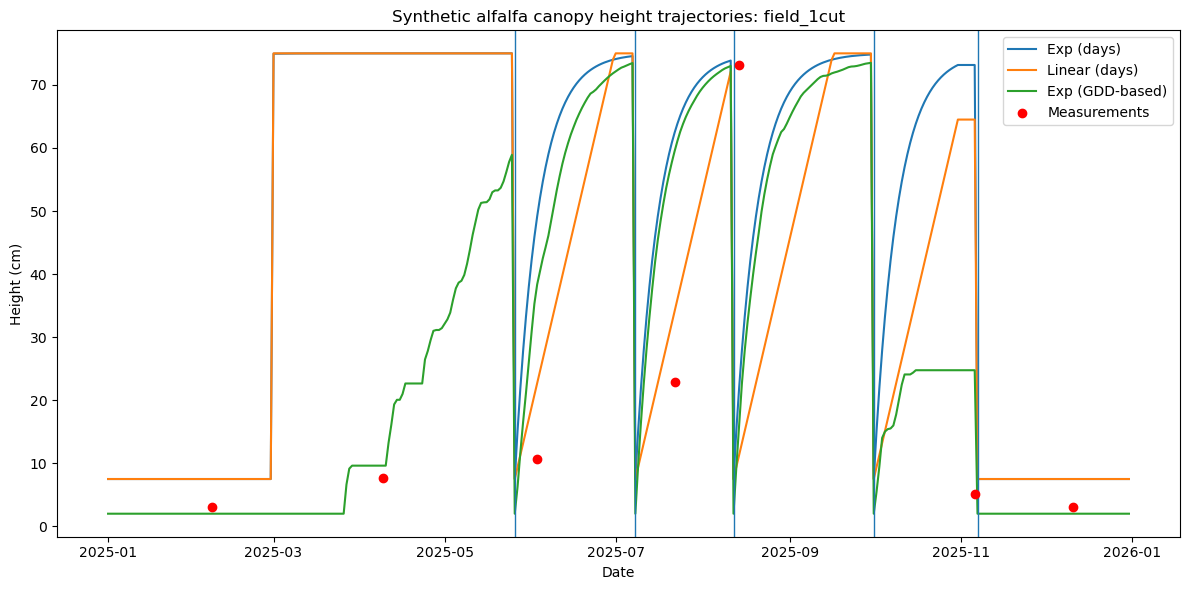

In [16]:

weather = pd.read_csv("PRISM_myton_celsius_2025.csv", parse_dates=["Date"],index_col="Date")

#
# # --- Synthetic cut schedules (1–4 cuts) ---
cut_schedules = {
    "field_1cut":  ["05/26/2025","07/08/2025","08/12/2025","10/1/2025","11/7/2025"],
}

# 
#  --- Synthetic modeling period (one year) ---
dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
doy = dates.dayofyear.to_numpy()

# Same weather for all fields in this demo
weather_by_field = {k: weather for k in cut_schedules.keys()}

# --- Define model parameter sets ---
# Day-based exponential
p_exp_days = AlfalfaHeightParams(
    h_resid_cm=7.5,
    h_max_cm=75.0,
    rate=0.12,        # k (day^-1) for 'exp' model; tune as needed
    model="exp",
    time_mode="days",
    dormancy_mode="doy",
)

# Day-based linear (simple)
p_lin_days = AlfalfaHeightParams(
    h_resid_cm=7.5,
    h_max_cm=75.0,
    rate=1.9,         # r (cm/day)
    model="linear",
    time_mode="days",
    dormancy_mode="doy",
)

# GDD-based exponential (thermal time)
p_exp_gdd = AlfalfaHeightParams(
    h_resid_cm=2.0,
    h_max_cm=75.0,
    rate=0.009,       # k_gdd (per GDD); tune as needed
    model="exp",
    time_mode="gdd",
    tbase_c= 10.0,
    tcap_c=30,      # optional cap (e.g., 30C) if you want
    dormancy_mode="temp",
    tmean_col="tmean_c",
)

# Run simulations
df_exp_days = simulate_alfalfa_height_multi_field(
    dates=dates,
    cut_dates_by_field=cut_schedules,
    default_params=p_exp_days,
    weather_by_field=weather_by_field,
)

df_lin_days = simulate_alfalfa_height_multi_field(
    dates=dates,
    cut_dates_by_field=cut_schedules,
    default_params=p_lin_days,
    weather_by_field=weather_by_field,
)

df_exp_gdd = simulate_alfalfa_height_multi_field(
    dates=dates,
    cut_dates_by_field=cut_schedules,
    default_params=p_exp_gdd,
    weather_by_field=weather_by_field,
)

meas_dates = ['2/7/2025','4/9/2025','6/3/2025','7/22/2025','8/14/2025','11/6/2025','12/11/2025']
meas_values = [0.1, 0.25, 0.35, 0.75, 2.4, 0.17, 0.1]
meas_df = pd.DataFrame(
    {"date": pd.to_datetime(meas_dates), "value": meas_values}
)
meas_df['height_cm'] = meas_df['value'] * 2.54 * 12  

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
field = "field_1cut"

ax.plot(df_exp_days.index, df_exp_days[field], label="Exp (days)")
ax.plot(df_lin_days.index, df_lin_days[field], label="Linear (days)")
ax.plot(df_exp_gdd.index, df_exp_gdd[field], label="Exp (GDD-based)")
ax.scatter(meas_df['date'], meas_df['height_cm'], color='red', label="Measurements", zorder=5)
# Add vertical lines for cuts
for cd in pd.to_datetime(cut_schedules[field]):
    ax.axvline(cd, linewidth=1)

ax.set_title(f"Synthetic alfalfa canopy height trajectories: {field}")
ax.set_ylabel("Height (cm)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
df_exp_gdd.rename(columns={'field_1cut': 'height_cm'}, inplace=True)
df_exp_gdd['height_ft'] = df_exp_gdd['height_cm'] / 30.48
df_exp_gdd['height_m'] = df_exp_gdd['height_cm'] / 100
df_exp_gdd.drop(columns=['height_cm'], inplace=True)
df_exp_gdd['measurement_type'] = 'gdd model'
df_exp_gdd['stationid']= 'US-UTV'
df_exp_gdd['observer'] = 'PCI'
df_exp_gdd = df_exp_gdd.round(2)
df_exp_gdd.to_csv("G:/Shared drives/UGS_Flux/Database/dynamic_crop_height/us_utv_alfalfa_height_exp_gdd.csv", index=True)